# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Sylfia Putri
- Email: Sylfia02@gmail.com
- Id Dicoding: Sylfia Putri

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv('data/data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Pada tahap ini kita akan memahami struktur data, mengecek kualitas data, dan melakukan Exploratory Data Analysis (EDA) untuk menemukan pola yang berkaitan dengan dropout mahasiswa.

### Struktur dan Tipe Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i



Dataset berisi informasi 4424 mahasiswa dengan 36 fitur input dan 1 target variable.
Target memiliki 3 kelas: **Dropout**, **Enrolled**, dan **Graduate**.

Fitur dikelompokkan menjadi:
- **Demografis**: marital status, gender, age, nationality, dll
- **Pendaftaran**: application mode, course, admission grade, dll  
- **Performa akademik**: unit enrolled/approved/grade semester 1 & 2
- **Faktor ekonomi**: scholarship, tuition fees, debtor, GDP, inflation, unemployment

Berdasarkan hasil eksplorasi awal menggunakan fungsi `df.info()`, seluruh variabel dalam dataset tidak memiliki missing values, sehingga data dapat langsung digunakan tanpa proses imputasi.

### Pengecekan Kualitas Data

In [4]:
df.duplicated().sum()

0

Tidak ada data yang duplicated

In [5]:
df.describe(include="all")

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


### Exploratory Data Analysis (EDA)

EDA dilakukan untuk menjawab pertanyaan:
- Dropout rate berapa %?
- Bagaimana distribusi status mahasiswa?
- Course mana paling banyak dropout?
- Gender mana lebih berisiko?
- Age distribution?
- Faktor ekonomi apa yang membedakan mahasiswa Dropout vs Graduate?
- Apakah performa akademik semester awal menjadi indikator kuat dropout?

In [6]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Berdasarkan hasil analisis, distribusi status mahasiswa adalah sebagai berikut:
- Graduate: 2209 mahasiswa
- Dropout: 1421 mahasiswa
- Enrolled: 794 mahasiswa

Mayoritas mahasiswa berada pada kategori graduate, yang menunjukkan bahwa sebagian besar mahasiswa berhasil menyelesaikan studinya.

Namun, jumlah mahasiswa yang mengalami dropout juga tergolong cukup tinggi, yaitu sekitar 32% dari total data. Hal ini menunjukkan adanya permasalahan yang signifikan dan perlu mendapatkan perhatian khusus dari institusi.

Distribusi data yang relatif seimbang antara kelas dropout dan non-dropout memungkinkan model machine learning untuk belajar dengan baik tanpa perlu penanganan khusus terhadap data imbalance.

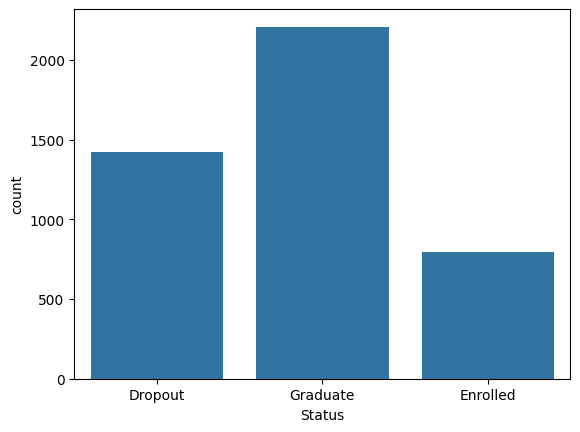

In [7]:
sns.countplot(x='Status', data=df)
plt.show()

In [8]:
dropout_rate = (df['Status'] == 'Dropout').mean() * 100
print(f"Dropout Rate: {dropout_rate:.2f}%")

Dropout Rate: 32.12%


In [9]:
df[df['Status'] == 'Dropout']['Course'].value_counts().head(10)

Course
9991    136
9147    134
9500    118
9773    101
9254     96
9670     95
9119     92
9085     90
9003     86
9853     85
Name: count, dtype: int64

Beberapa fitur kategorikal dalam dataset direpresentasikan dalam bentuk numerik (misalnya 0 dan 1), sehingga kurang intuitif untuk kebutuhan analisis dan visualisasi. Oleh karena itu, dilakukan transformasi dengan mengubah nilai numerik menjadi label yang lebih deskriptif agar hasil visualisasi lebih mudah dipahami.

Fitur yang ditransformasi meliputi:
- Gender: 0 → Female, 1 → Male  
- Tuition fees up to date: 0 → Not paid, 1 → Up to date  
- Scholarship holder: 0 → No, 1 → Yes  
- Debtor: 0 → No, 1 → Yes  
- Daytime/evening attendance: 0 → Evening, 1 → Daytime  
- Marital status: diubah menjadi label seperti Single, Married, dan lainnya  
- Course: diubah menjadi nama program studi yang lebih deskriptif  

Transformasi hanya dilakukan pada fitur yang relevan dan memiliki jumlah kategori terbatas. Kolom asli tetap dipertahankan untuk keperluan pemodelan, sedangkan kolom hasil transformasi digunakan untuk analisis dan visualisasi.

In [10]:
df_label = df.copy()

In [11]:
df_label['Gender_label'] = df_label['Gender'].map({1: 'Male', 0: 'Female'})

In [12]:
df_label['Tuition_label'] = df_label['Tuition_fees_up_to_date'].map({1: 'Up to date', 0: 'Not paid'})

In [13]:
df_label['Scholarship_label'] = df_label['Scholarship_holder'].map({1: 'Yes', 0: 'No'})

In [14]:
df_label['Debtor_label'] = df_label['Debtor'].map({1: 'Yes', 0: 'No'})

In [15]:
df_label['Attendance_label'] = df_label['Daytime_evening_attendance'].map({1: 'Daytime', 0: 'Evening'})

In [16]:
df_label['Marital_label'] = df_label['Marital_status'].map({
    1: 'Single',
    2: 'Married',
    3: 'Widower',
    4: 'Divorced',
    5: 'Factouion',
    6: 'legally separated'
})

In [17]:
course_mapping = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (Evening)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equinculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (Evening)"
}

df_label['Course_label'] = df_label['Course'].map(course_mapping)

In [18]:
df_label[df_label['Status'] == 'Dropout']['Course_label'].value_counts().head(10)

Course_label
Management (Evening)                    136
Management                              134
Nursing                                 118
Journalism and Communication            101
Tourism                                  96
Advertising and Marketing Management     95
Informatics Engineering                  92
Veterinary Nursing                       90
Agronomy                                 86
Basic Education                          85
Name: count, dtype: int64

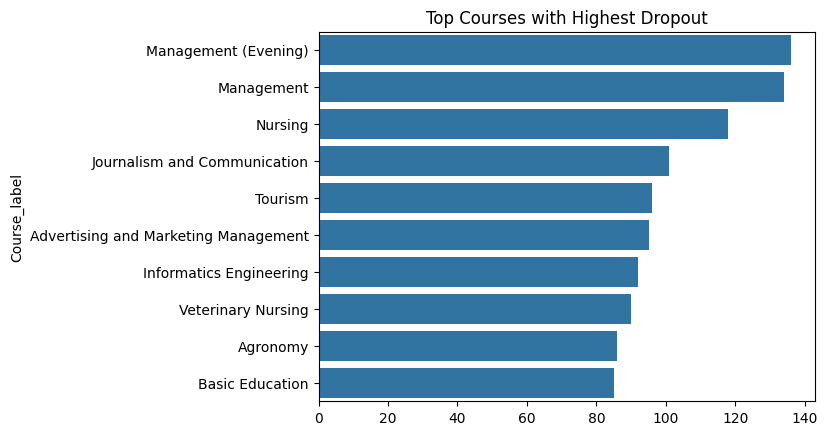

In [19]:
top_course = df_label[df_label['Status']=='Dropout']['Course_label'].value_counts().head(10)

sns.barplot(x=top_course.values, y=top_course.index)
plt.title('Top Courses with Highest Dropout')
plt.show()

Berdasarkan hasil analisis, program studi dengan jumlah mahasiswa dropout tertinggi adalah Management (Evening) dan Management, diikuti oleh Nursing serta Journalism and Communication.

Hal ini menunjukkan bahwa beberapa program studi tertentu memiliki tingkat dropout yang lebih tinggi dibandingkan yang lain. Kondisi ini dapat mengindikasikan adanya faktor akademik, beban studi, atau karakteristik mahasiswa yang memengaruhi tingkat keberhasilan studi pada program tersebut.

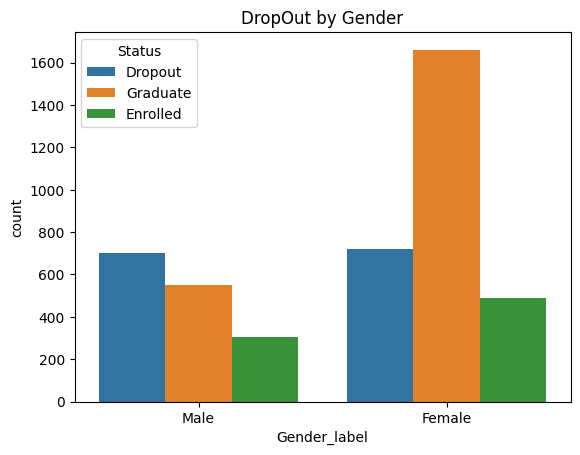

In [20]:
sns.countplot(x='Gender_label', hue='Status', data=df_label)
plt.title("DropOut by Gender")
plt.show()

Distribusi menunjukkan bahwa jumlah dropout antara laki-laki dan perempuan relatif tidak jauh berbeda. Namun, jumlah mahasiswa perempuan yang lulus lebih tinggi dibandingkan laki-laki. Hal ini mengindikasikan bahwa gender bukan faktor utama yang memengaruhi dropout secara signifikan.

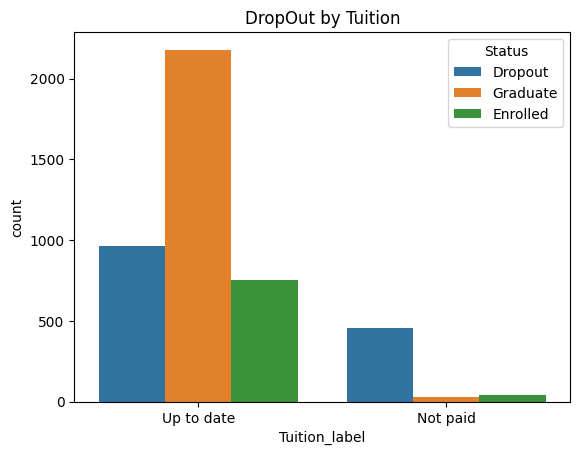

In [21]:
sns.countplot(x='Tuition_label', hue='Status', data=df_label)
plt.title("DropOut by Tuition")
plt.show()

Mahasiswa yang tidak membayar biaya kuliah (not paid) memiliki jumlah dropout yang relatif tinggi dibandingkan dengan yang membayar tepat waktu. Hal ini menunjukkan bahwa faktor finansial memiliki pengaruh kuat terhadap kemungkinan mahasiswa mengalami dropout.

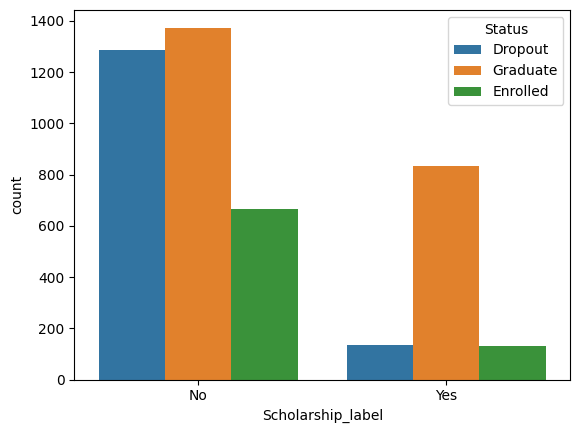

In [22]:
sns.countplot(x='Scholarship_label', hue='Status', data=df_label)
plt.show()

Mahasiswa yang tidak menerima beasiswa memiliki jumlah dropout yang lebih tinggi dibandingkan yang menerima beasiswa. Hal ini menunjukkan bahwa dukungan finansial melalui beasiswa dapat membantu menurunkan risiko dropout.

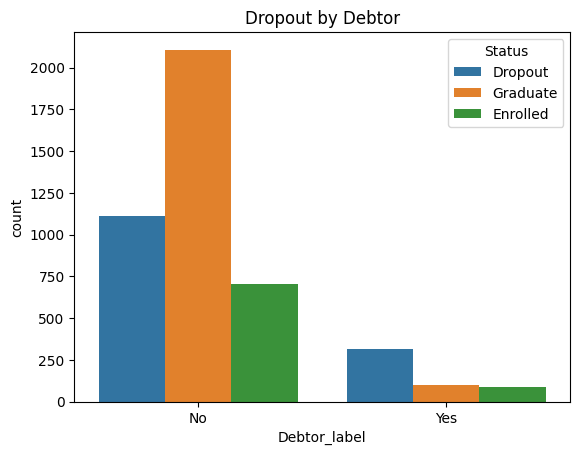

In [23]:
sns.countplot(x='Debtor_label', hue='Status', data=df_label)
plt.title("Dropout by Debtor")
plt.show()

Mahasiswa yang memiliki hutang (debtor) cenderung memiliki jumlah dropout yang lebih tinggi dibandingkan yang tidak memiliki hutang. Ini mengindikasikan bahwa kondisi finansial yang kurang stabil menjadi salah satu faktor utama penyebab dropout.

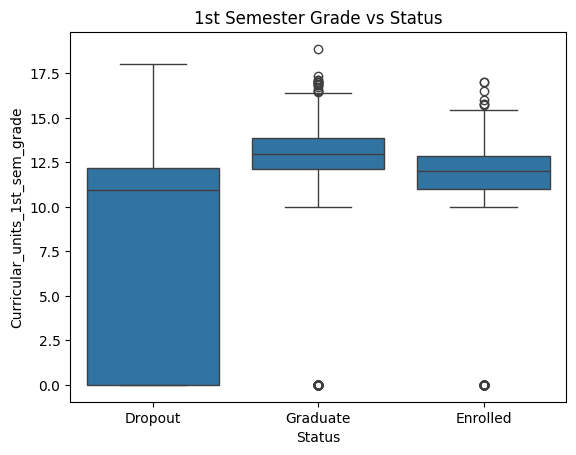

In [24]:
sns.boxplot(x='Status', y='Curricular_units_1st_sem_grade', data=df_label)
plt.title('1st Semester Grade vs Status')
plt.show()

Mahasiswa dengan status dropout memiliki distribusi nilai semester pertama yang lebih rendah dibandingkan mahasiswa yang lulus. Hal ini menunjukkan bahwa performa akademik pada semester awal merupakan indikator kuat terhadap kemungkinan dropout.

In [25]:
numeric_cols = [
    'Gender',
    'Course',
    'Age_at_enrollment',
    'Debtor',
    'Marital_status',
    'Scholarship_holder',
    'Tuition_fees_up_to_date',
    'Admission_grade',
    'Inflation_rate'
]

numeric_df = df[numeric_cols]

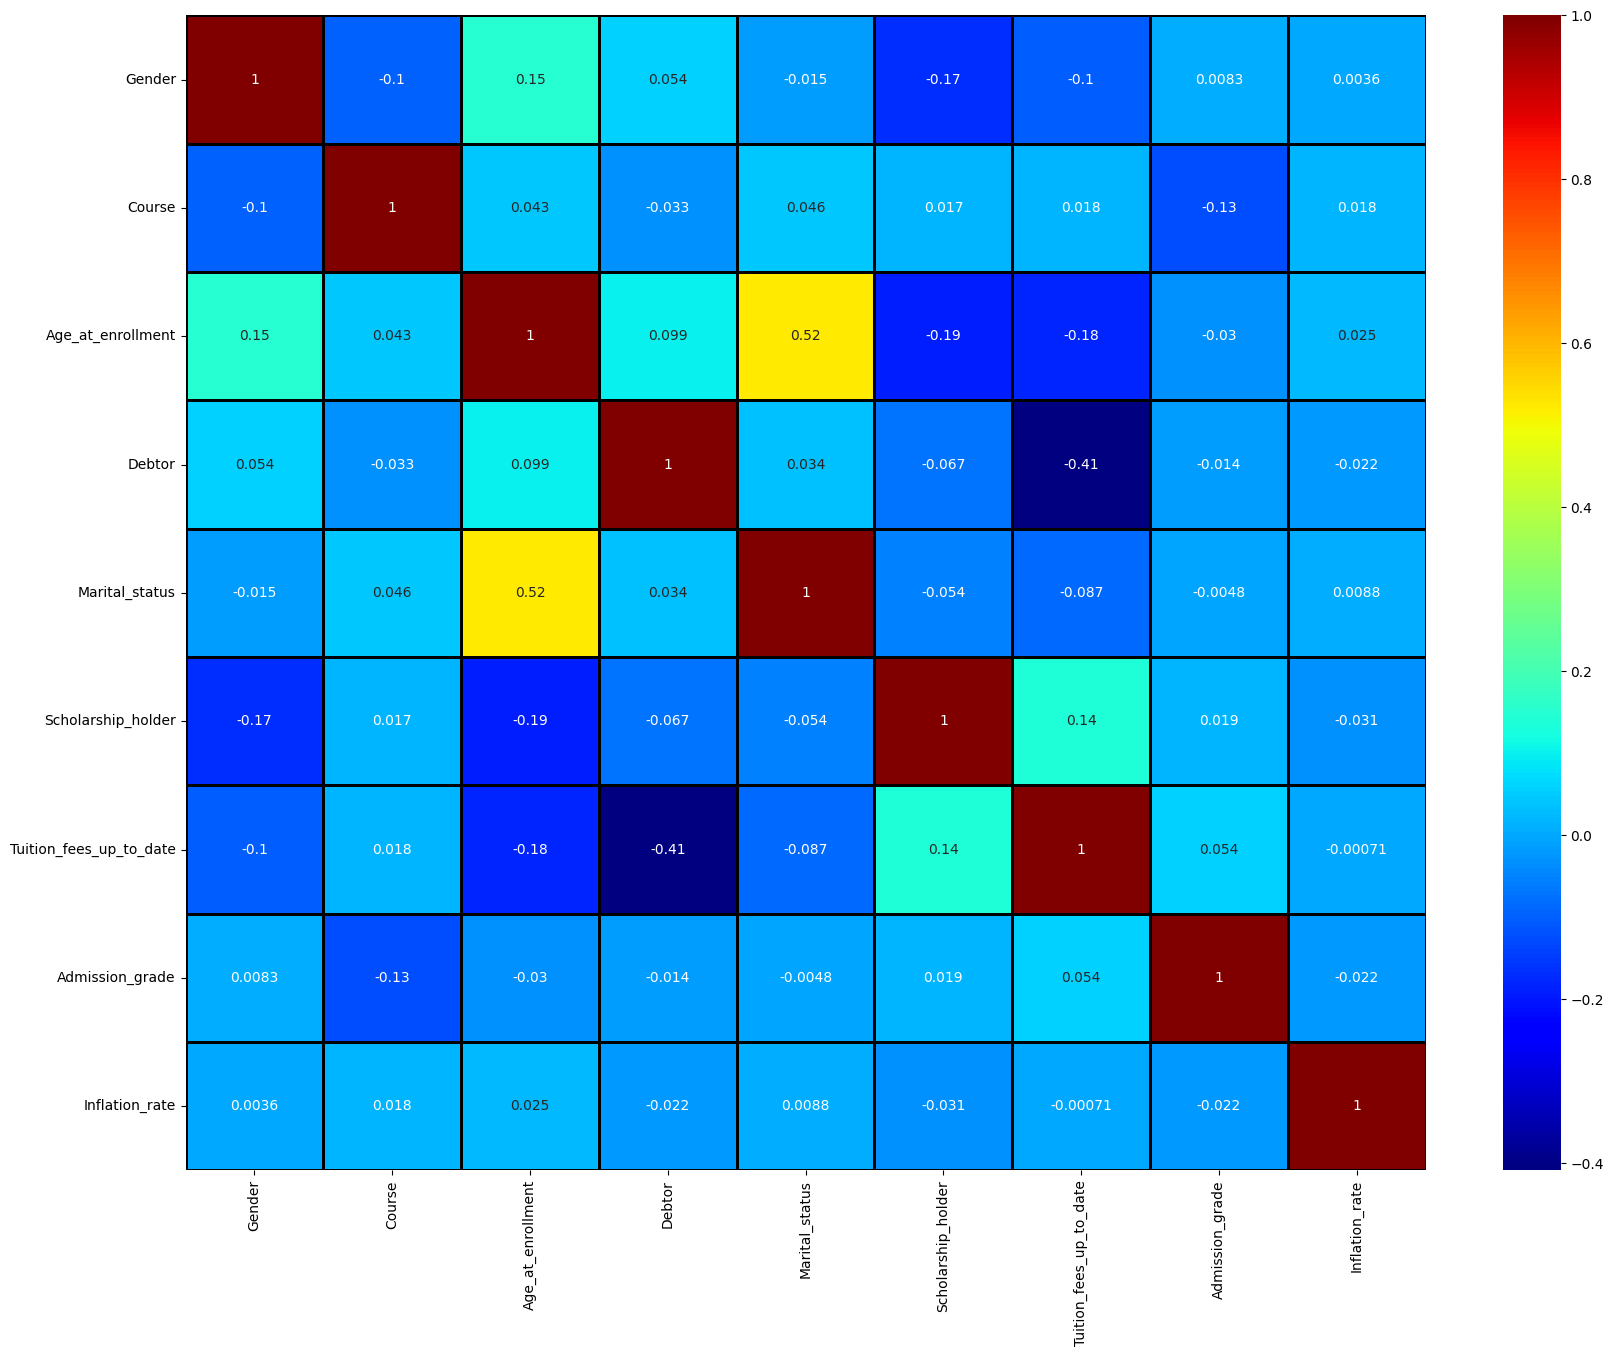

In [26]:
plt.figure(figsize=(20,15))
sns.heatmap(numeric_df.corr(), annot=True, cmap='jet', linecolor='black', linewidth=1)
plt.show()

Sebagian besar variabel memiliki korelasi yang rendah satu sama lain, yang menunjukkan bahwa tidak ada hubungan linear yang kuat antar fitur. Namun, terdapat korelasi negatif yang cukup terlihat antara status pembayaran biaya kuliah dan status hutang, yang mengindikasikan keterkaitan antara kondisi finansial mahasiswa.

Secara keseluruhan, faktor finansial (seperti pembayaran biaya kuliah dan status hutang) serta performa akademik awal memiliki pengaruh paling signifikan terhadap kemungkinan mahasiswa mengalami dropout. Sementara itu, faktor demografis seperti gender memiliki pengaruh yang relatif kecil.

## Data Preparation / Preprocessing

## Data Preparation

Data preprocessing merupakan tahapan penting dalam proyek data science yang bertujuan untuk menyiapkan data agar siap digunakan dalam proses pemodelan. Pada tahap ini dilakukan beberapa proses transformasi agar data memiliki kualitas yang baik dan sesuai dengan kebutuhan model.

Pada proyek ini, tahapan data preparation yang dilakukan meliputi:

1. **Data Splitting**  
   Dataset dibagi menjadi dua bagian, yaitu data latih (training set) dan data uji (testing set), dengan tujuan untuk mengevaluasi performa model secara objektif.

2. **Handling Imbalanced Data**  
   Untuk mengatasi ketidakseimbangan jumlah kelas, digunakan teknik undersampling agar distribusi data menjadi lebih seimbang dan model tidak bias terhadap kelas mayoritas.

3. **Data Transformation**  
   - Encoding dilakukan pada fitur kategorikal untuk mengubah data menjadi bentuk numerik.  
   - Scaling diterapkan pada fitur numerik untuk menyamakan skala antar variabel sehingga model dapat belajar dengan lebih optimal.

4. **Dimensionality Reduction & Multicollinearity Handling**  
   Dilakukan reduksi dimensi serta penanganan multikolinearitas pada fitur numerik untuk mengurangi redundansi informasi dan meningkatkan efisiensi model.

Secara keseluruhan, tahap ini bertujuan untuk memastikan bahwa data dalam kondisi optimal sehingga dapat menghasilkan model yang lebih akurat dan robust.

### Data Splitting

In [28]:
selected_features = [
 'Gender',
 'Course',
 'Age_at_enrollment',
 'Debtor',
 'Marital_status',
 'Scholarship_holder',
 'Tuition_fees_up_to_date',
 'Admission_grade',
 'Inflation_rate'
]

df_model = df[selected_features + ['Status']]
df_model.head()

,Gender,Course,Age_at_enrollment,Debtor,Marital_status,Scholarship_holder,Tuition_fees_up_to_date,Admission_grade,Inflation_rate,Status
0,1,171,20,0,1,0,1,127.3,1.4,Dropout
1,1,9254,19,0,1,0,0,142.5,-0.3,Graduate
2,1,9070,19,0,1,0,0,124.8,1.4,Dropout
3,0,9773,20,0,1,0,1,119.6,-0.8,Graduate
4,0,8014,45,0,2,0,1,141.5,-0.3,Graduate


In [ ]:
from sklearn.model_selection import train_test_split

# pilih fitur
selected_features = [
 'Gender',
 'Course',
 'Age_at_enrollment',
 'Debtor',
 'Marital_status',
 'Scholarship_holder',
 'Tuition_fees_up_to_date',
 'Admission_grade',
 'Inflation_rate'
]

df_model = df[selected_features + ['Status']]


# split
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# reset index
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3539, 10)
Test shape: (885, 10)


Pada tahap ini, dataset dibagi menjadi dua bagian, yaitu data latih (training set) dan data uji (testing set). Pembagian dilakukan dengan perbandingan 80% untuk data latih dan 20% untuk data uji menggunakan fungsi train_test_split() dari library scikit-learn.

Data latih digunakan untuk melatih model, sedangkan data uji digunakan untuk mengevaluasi performa model terhadap data yang belum pernah dilihat sebelumnya.

Berdasarkan proses yang dilakukan, diperoleh:

Data latih: 3.539 data
Data uji: 885 data

Pembagian ini bertujuan untuk menghindari overfitting serta memastikan model memiliki kemampuan generalisasi yang baik

In [35]:
train_df.head()

,Gender,Course,Age_at_enrollment,Debtor,Marital_status,Scholarship_holder,Tuition_fees_up_to_date,Admission_grade,Inflation_rate,Status
0,0,9147,35,0,4,0,1,130.0,0.6,Dropout
1,0,9085,25,0,1,1,1,110.0,0.6,Enrolled
2,1,9070,22,0,1,0,1,123.2,1.4,Graduate
3,1,9238,42,0,2,0,1,103.5,2.8,Dropout
4,0,9500,22,0,1,1,1,137.3,2.6,Graduate


### Undersampling

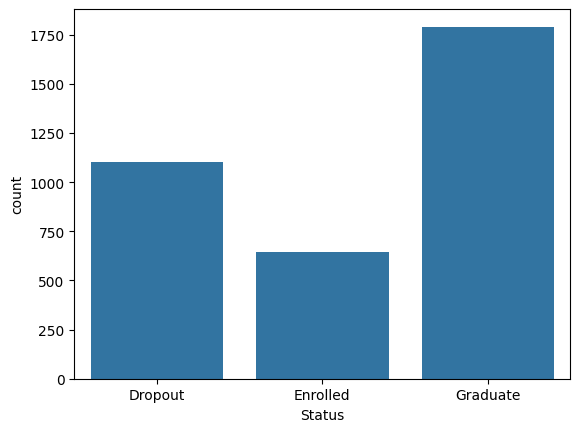

In [43]:


sns.countplot(data=train_df, x="Status")
plt.show()

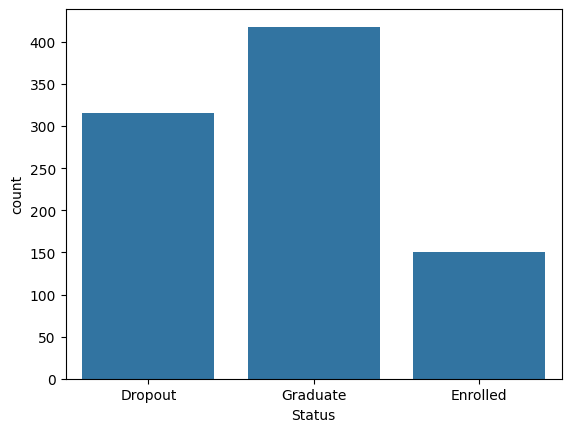

In [44]:
sns.countplot(data=test_df, x="Status")
plt.show()

Berdasarkan hasil visualisasi, terlihat bahwa distribusi data pada variabel target (Target) tidak seimbang, di mana jumlah mahasiswa non-dropout lebih banyak dibandingkan mahasiswa dropout. Kondisi ini menunjukkan adanya imbalanced data yang berpotensi menyebabkan model menjadi bias terhadap kelas mayoritas.

In [45]:
train_df['Status'].value_counts()

Status
Graduate    1791
Dropout     1105
Enrolled     643
Name: count, dtype: int64

Untuk menangani permasalahan imbalance, dilakukan analisis jumlah sampel pada masing-masing kelas. Kelas dengan jumlah data lebih sedikit disebut sebagai kelas minoritas, sedangkan kelas dengan jumlah data lebih banyak disebut sebagai kelas mayoritas.

In [46]:
df_majority_1 = train_df[(train_df.Status == 'Graduate')]  
df_majority_2 = train_df[(train_df.Status == 'Dropout')]
df_minority = train_df[(train_df.Status == 'Enrolled')] 

In [48]:
from sklearn.utils import resample

df_majority_1_undersampled = resample(df_majority_1, n_samples=643, random_state=42) # Undersampling
df_majority_2_undersampled = resample(df_majority_2, n_samples=643, random_state=42)
print(df_majority_1_undersampled.shape)
print(df_majority_2_undersampled.shape)

(643, 10)
(643, 10)


In [49]:
from sklearn.utils import shuffle

undersampled_train_df = pd.concat([df_minority, df_majority_1_undersampled]).reset_index(drop=True)
undersampled_train_df = pd.concat([undersampled_train_df, df_majority_2_undersampled]).reset_index(drop=True)
undersampled_train_df = shuffle(undersampled_train_df, random_state=42)
undersampled_train_df.reset_index(drop=True, inplace=True)
undersampled_train_df.sample(5)

,Gender,Course,Age_at_enrollment,Debtor,Marital_status,Scholarship_holder,Tuition_fees_up_to_date,Admission_grade,Inflation_rate,Status
730,0,9085,32,0,1,0,1,120.0,2.8,Dropout
556,0,9500,19,0,1,0,1,128.3,1.4,Graduate
1381,1,9500,24,1,1,0,1,100.0,3.7,Dropout
372,1,9147,19,0,1,0,1,117.0,0.5,Enrolled
1531,0,9085,22,0,1,0,1,130.0,0.5,Enrolled


In [54]:
undersampled_train_df.Status.value_counts()

Status
Graduate    643
Dropout     643
Enrolled    643
Name: count, dtype: int64

In [51]:
undersampled_train_df.shape

(1929, 10)

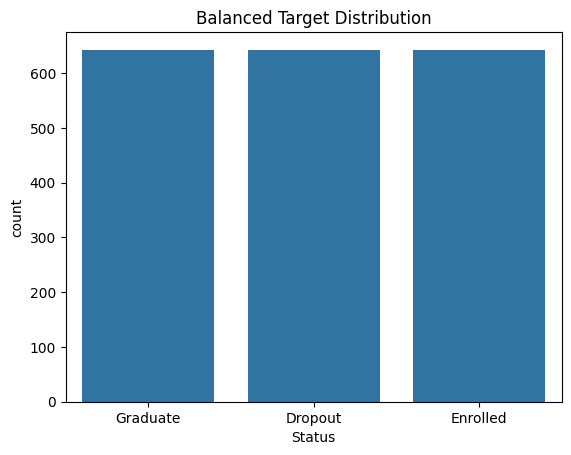

In [55]:
sns.countplot(data=undersampled_train_df, x="Status")
plt.title("Balanced Target Distribution")
plt.show()


Untuk mengatasi ketidakseimbangan data, digunakan teknik undersampling dengan cara mengurangi jumlah sampel pada kelas mayoritas (non-dropout) sehingga jumlahnya seimbang dengan kelas minoritas (dropout).

Proses ini dilakukan dengan mengambil sampel secara acak dari kelas mayoritas menggunakan fungsi resample(). Setelah itu, data dari kedua kelas digabungkan kembali dan diacak menggunakan fungsi shuffle().

Hasil dari proses ini menunjukkan bahwa distribusi data menjadi seimbang, sehingga diharapkan model dapat belajar dengan lebih baik tanpa bias terhadap kelas mayoritas.

### Encoding & Scaling

In [59]:
X_train = undersampled_train_df.drop(columns="Status", axis=1)
y_train = undersampled_train_df["Status"]

X_test = test_df.drop(columns="Status", axis=1)
y_test = test_df["Status"]

Pada tahap ini, dataset dipisahkan menjadi feature (X) dan target (y). Feature digunakan sebagai input model, sedangkan target merupakan variabel yang ingin diprediksi, yaitu status dropout mahasiswa.

In [67]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np
import joblib

def scaling(features, df, df_test=None):
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature]).reshape(-1,1)
            scaler.fit(X)
            df[feature] = scaler.transform(X)
            joblib.dump(scaler, f"model/scaler_{feature}.joblib")

            X_test = np.asanyarray(df_test[feature]).reshape(-1,1)
            df_test[feature] = scaler.transform(X_test)
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature]).reshape(-1,1)
            scaler.fit(X)
            df[feature] = scaler.transform(X)
            joblib.dump(scaler, f"model/scaler_{feature}.joblib")
        return df


def encoding(features, df, df_test=None):
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            encoder = LabelEncoder()
            encoder.fit(df[feature])
            df[feature] = encoder.transform(df[feature])
            joblib.dump(encoder, f"model/encoder_{feature}.joblib")

            df_test[feature] = encoder.transform(df_test[feature])
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            encoder = LabelEncoder()
            encoder.fit(df[feature])
            df[feature] = encoder.transform(df[feature])
            joblib.dump(encoder, f"model/encoder_{feature}.joblib")
        return df

Pada tahap ini dilakukan proses scaling dan encoding. Scaling menggunakan MinMaxScaler untuk menormalkan fitur numerik ke dalam rentang 0–1, sedangkan encoding menggunakan LabelEncoder untuk mengubah fitur kategorikal menjadi numerik. Seluruh objek scaler dan encoder disimpan dalam format .joblib agar dapat digunakan kembali pada tahap deployment

In [68]:
numerical_columns = [
    'Age_at_enrollment',
    'Admission_grade',
    'Inflation_rate'
]

categorical_columns = [
    'Gender',
    'Course',
    'Debtor',
    'Marital_status',
    'Scholarship_holder',
    'Tuition_fees_up_to_date'
]


Pada tahap ini, fitur kategorikal seperti Gender, Course, Debtor, Marital Status, Scholarship Holder, dan Tuition Fees Up to Date diubah menjadi bentuk numerik menggunakan LabelEncoder.


In [71]:
def encoding(categorical_columns, df, df_test):

    for feature in categorical_columns:
        encoder = LabelEncoder()

        # gabung train + test
        combined = pd.concat([df[feature], df_test[feature]], axis=0).astype(str)

        # fit dari gabungan
        encoder.fit(combined)

        # transform
        df[feature] = encoder.transform(df[feature].astype(str))
        df_test[feature] = encoder.transform(df_test[feature].astype(str))

        # save encoder
        joblib.dump(encoder, f"model/encoder_{feature}.joblib")

    return df, df_test

Encoder dilatih menggunakan gabungan data latih dan data uji untuk menghindari error akibat kategori yang tidak dikenali. Selanjutnya, hasil encoding diterapkan pada kedua dataset, dan setiap encoder disimpan dalam file .joblib untuk digunakan kembali pada tahap deploymen

In [78]:
# scaling dulu
new_train_df, new_test_df = scaling(numerical_columns, X_train, X_test)

# encoding
new_train_df, new_test_df = encoding(categorical_columns, new_train_df, new_test_df)

In [72]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

encoder.fit(y_train)
new_y_train = encoder.transform(y_train)

joblib.dump(encoder, "model/encoder_target.joblib")

new_y_test = encoder.transform(y_test)

In [73]:
new_y_train

array([2, 0, 0, ..., 2, 0, 2])

Variabel target juga dikonversi ke bentuk numerik agar dapat digunakan dalam proses pelatihan model. Selain itu, encoder disimpan dalam bentuk file untuk memastikan konsistensi pada tahap deployment.

Selain itu, objek scaler dan encoder disimpan dalam format .joblib agar dapat digunakan kembali pada proses deployment. Hal ini penting untuk memastikan bahwa data baru diproses dengan cara yang sama seperti data saat pelatihan model.

## Modeling

Pada tahap ini digunakan algoritma Random Forest  untuk membangun model klasifikasi. Model kemudian dioptimasi menggunakan metode GridSearchCV untuk mencari kombinasi parameter terbaik, seperti jumlah pohon (n_estimators), kedalaman pohon (max_depth), jumlah fitur (max_features), dan kriteria pemisahan (criterion)

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib

In [103]:
rdf_model = RandomForestClassifier(random_state=42)

In [104]:
param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [6, 8, 10],
    'criterion': ['gini', 'entropy']
}


In [105]:
CV_rdf = GridSearchCV(
    estimator=rdf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

CV_rdf.fit(new_train_df, new_y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [6, 8, 10],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [200, 500]})

Proses GridSearchCV dilakukan dengan teknik cross-validation sebanyak 5 fold untuk memastikan model memiliki performa yang optimal dan tidak overfitting. Model dilatih menggunakan data latih yang telah melalui proses preprocessing

In [106]:
print("Best Parameters:", CV_rdf.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}


Hasil dari GridSearchCV menunjukkan kombinasi hyperparameter terbaik yang menghasilkan performa optimal pada data latih.

Model terbaik menggunakan:
- criterion = gini → untuk mengukur kualitas split
- max_depth = 10 → kedalaman pohon cukup dalam untuk menangkap pola
- max_features = log2 → jumlah fitur yang dipertimbangkan pada setiap split
- n_estimators = 200 → jumlah pohon dalam forest

Parameter ini digunakan sebagai acuan dalam membangun model final.

In [107]:
rdf_model = RandomForestClassifier(
    random_state=42,
    max_depth=8,
    n_estimators=200,
    max_features='log2',
    criterion='gini',
    n_jobs=-1
)

rdf_model.fit(new_train_df, new_y_train)

RandomForestClassifier(max_depth=8, max_features='log2', n_estimators=200,
                       n_jobs=-1, random_state=42)

In [108]:
joblib.dump(rdf_model, "model/rf_model.joblib")

['model/rf_model.joblib']

Model yang telah dilatih disimpan dalam format .joblib untuk digunakan kembali pada tahap deployment.Penyimpanan model ini memungkinkan sistem untuk melakukan prediksi tanpa perlu melatih ulang model dari awal.

Pada tahap ini digunakan algoritma Random Forest untuk membangun model klasifikasi dalam memprediksi kemungkinan mahasiswa mengalami dropout.Random Forest merupakan metode ensemble yang menggabungkan banyak decision tree untuk menghasilkan prediksi yang lebih akurat dan stabil.
Untuk mendapatkan performa terbaik, dilakukan hyperparameter tuning menggunakan GridSearchCV dengan beberapa parameter seperti jumlah tree (n_estimators), kedalaman tree (max_depth), jumlah fitur (max_features), dan kriteria pemisahan (criterion).
Model terbaik kemudian dilatih menggunakan parameter optimal dan disimpan untuk digunakan pada tahap selanjutnya.

## Evaluation

Pada tahap evaluasi, model diuji menggunakan data uji untuk mengetahui performanya dalam melakukan prediksi. Hasil prediksi model dibandingkan dengan nilai aktual menggunakan classification report dan confusion matrix.

Selain itu, hasil prediksi yang masih dalam bentuk numerik dikembalikan ke bentuk label asli menggunakan encoder. Confusion matrix divisualisasikan untuk melihat distribusi prediksi benar dan salah pada setiap kelas.

Evaluasi ini bertujuan untuk mengukur tingkat akurasi, precision, recall, dan F1-score dari model yang telah dibangun

In [91]:
from sklearn.metrics import classification_report, confusion_matrix

In [84]:
y_pred = rdf_model.predict(new_test_df)

In [90]:
encoder_target = joblib.load("model/encoder_target.joblib")

y_pred_label = encoder_target.inverse_transform(y_pred)
y_test_label = encoder_target.inverse_transform(new_y_test)

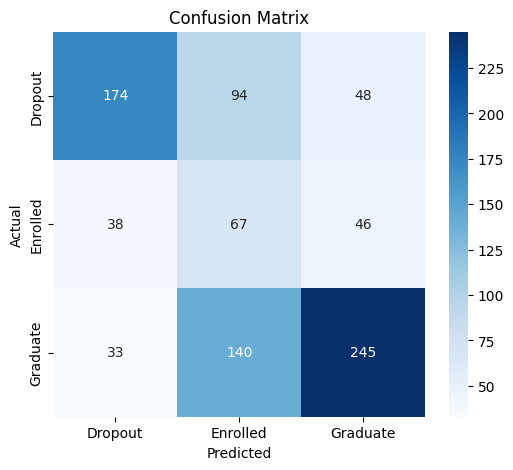

In [92]:
labels = encoder_target.classes_

cm = confusion_matrix(y_test_label, y_pred_label, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Confusion matrix digunakan untuk melihat performa model dalam mengklasifikasikan data ke dalam kelas yang benar.

Matrix ini menunjukkan jumlah prediksi benar dan salah untuk setiap kelas, sehingga dapat membantu memahami kesalahan yang dilakukan oleh model.

In [94]:
from sklearn.metrics import classification_report

print(classification_report(new_y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.55      0.62       316
           1       0.22      0.44      0.30       151
           2       0.72      0.59      0.65       418

    accuracy                           0.55       885
   macro avg       0.55      0.53      0.52       885
weighted avg       0.63      0.55      0.58       885



In [87]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(new_y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5491525423728814


Berdasarkan hasil evaluasi menggunakan classification report, model memiliki tingkat akurasi sebesar 55%, yang menunjukkan bahwa performa model masih berada pada kategori moderat.

Secara lebih rinci, model menunjukkan performa yang cukup baik dalam mengklasifikasikan kelas Dropout dan Graduate, dengan nilai precision dan recall yang relatif lebih tinggi dibandingkan kelas lainnya. Hal ini mengindikasikan bahwa model mampu mengenali pola pada kedua kelas tersebut dengan cukup baik.

Namun, model mengalami kesulitan dalam mengklasifikasikan kelas Enrolled, yang ditunjukkan oleh nilai precision sebesar 0.22 dan recall sebesar 0.44. Nilai ini menunjukkan bahwa banyak data pada kelas Enrolled yang tidak teridentifikasi dengan benar, baik sebagai false positive maupun false negative.

Selain itu, nilai macro average dan weighted average yang berada di kisaran 0.52 – 0.58 menunjukkan bahwa performa model secara keseluruhan masih belum optimal dan terdapat ketidakseimbangan kemampuan model dalam memprediksi masing-masing kelas.

Dengan demikian, dapat disimpulkan bahwa model masih perlu dilakukan pengembangan lebih lanjut, khususnya dalam meningkatkan kemampuan klasifikasi pada kelas Enrolled agar performa model menjadi lebih seimbang dan akurat.

## CONCLUSION

Berdasarkan hasil analisis data dan pemodelan yang telah dilakukan, dapat disimpulkan bahwa model Random Forest mampu memprediksi kemungkinan mahasiswa mengalami dropout dengan performa yang cukup baik.

Model berhasil mengidentifikasi sebagian besar mahasiswa yang berpotensi dropout, meskipun masih terdapat beberapa kesalahan prediksi, terutama pada kasus mahasiswa dropout yang tidak terdeteksi (false negative).

Dari hasil Exploratory Data Analysis (EDA), ditemukan beberapa faktor yang berpengaruh terhadap dropout, seperti status pembayaran biaya kuliah, kepemilikan beasiswa, performa akademik pada semester awal, serta faktor demografis seperti usia dan gender.

Dengan demikian, model ini dapat digunakan sebagai alat bantu untuk mendeteksi risiko dropout sejak dini dan mendukung pengambilan keputusan yang lebih tepat oleh institusi pendidikan.

In [101]:
df_label.to_csv("data/data_label.csv", index=False)